# Import et Configuration

In [15]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

Cette gestion des chemins est préférable à un chemin absolu car cela risque d'empêcher une autre personne d'exécuter facilement le projet.

# Chargement du jeu de donnée

In [16]:
train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Train shape : {train_df.shape}")
print(f"Test shape: {test_df.shape}")

train_df.head()

Train shape : (891, 12)
Test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Vérification intiales

In [17]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [18]:
train_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


In [19]:
print("Nombre de doublons :", train_df.duplicated().sum())

Nombre de doublons : 0


In [20]:
missing_values = (
    train_df.isna()
    .sum()
    .to_frame(name="missing_count")
    .assign(
        missing_rate=lambda df: (
            100 * df["missing_count"] / len(train_df)
        ).round(2)
    )
    .sort_values("missing_rate", ascending=False)
)

missing_values

,missing_count,missing_rate
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


# Contrôle de la cible

In [21]:
train_df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [22]:
target_distribution = (
    train_df["Survived"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

target_distribution

Survived
0    61.62
1    38.38
Name: proportion, dtype: float64

### Visualisation

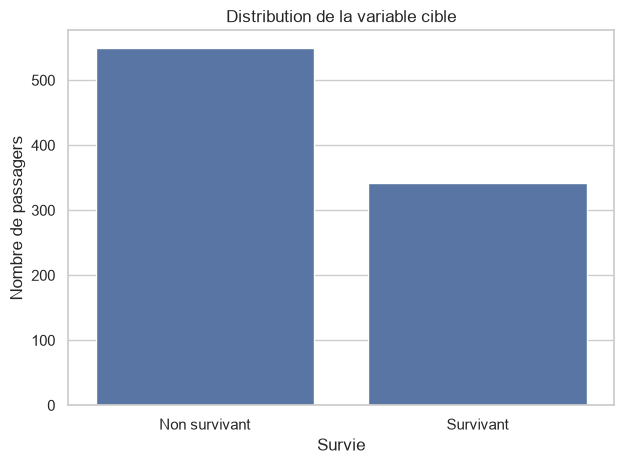

In [23]:
ax = sns.countplot(data=train_df, x="Survived")

ax.set(
    title="Distribution de la variable cible",
    xlabel="Survie",
    ylabel="Nombre de passagers"
)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Non survivant", "Survivant"])

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Premières questions d'analyse

On va commencer par regarder le taux et le nombre de survivant selon le sexe de chaque passager

In [24]:
train_df.groupby("Sex")["Survived"].agg(["mean", "count"])

,mean,count
Sex,,
female,0.742038,314
male,0.188908,577


On regarde ensuite le taux et le nombre de survivant selon les différentes classes des passagers 

In [25]:
train_df.groupby("Pclass")["Survived"].agg(["mean", "count"])

,mean,count
Pclass,,
1,0.629630,216
2,0.472826,184
3,0.242363,491


On va venir le voir sous forme de tableau croisée

In [26]:
train_df.groupby(["Sex", "Pclass"])["Survived"].agg(["mean", "count"])

mean  count
Sex    Pclass                 
female 1       0.968085     94
       2       0.921053     76
       3       0.500000    144
male   1       0.368852    122
       2       0.157407    108
       3       0.135447    347

sous forme de graphique on a

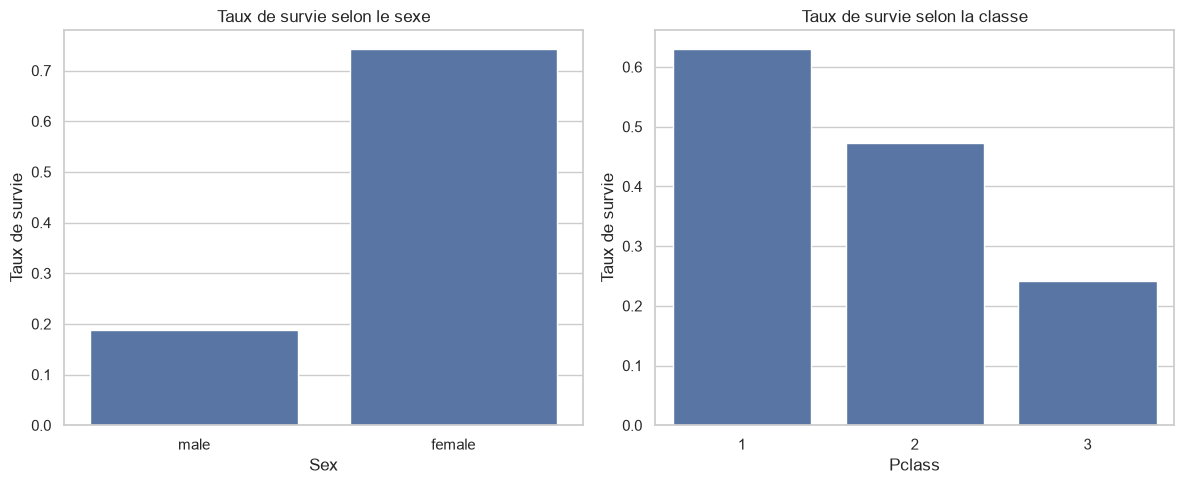

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(
    data=train_df,
    x="Sex",
    y="Survived",
    errorbar=None,
    ax=axes[0]
)
axes[0].set_title("Taux de survie selon le sexe")
axes[0].set_ylabel("Taux de survie")

sns.barplot(
    data=train_df,
    x="Pclass",
    y="Survived",
    errorbar=None,
    ax=axes[1]
)
axes[1].set_title("Taux de survie selon la classe")
axes[1].set_ylabel("Taux de survie")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "survival_by_sex_and_class.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

on va venir voir le graphique pour la distribution de l'âge

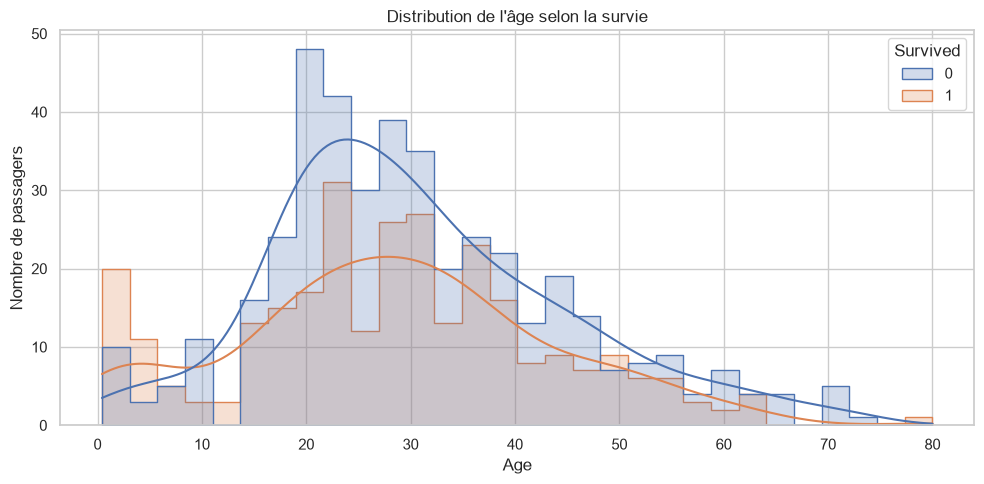

In [28]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=train_df,
    x="Age",
    hue="Survived",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Distribution de l'âge selon la survie")
plt.xlabel("Age")
plt.ylabel("Nombre de passagers")

plt.tight_layout()
plt.show()

### Interprétation
On constate que le taux de survie semblre plus élevé chez les femmes que chez les hommes. Que la classe du billet semble également associée à la survie, les passagers de premières classe présentant un taux de survie supérieur. Ces résultats restent descriptif et ne permettent pas, à eux seuls, d'établir une relation causale.